<a href="https://colab.research.google.com/github/MURALAAYYAPPA/Data-Visualization/blob/main/Exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("iris.csv")
df.columns=['sepal_length','sepal_width','petal_length','petal_width','species']
df_group=df.groupby(['species','petal_width']).size().reset_index(name='count')
df_group['petal_width'] = df_group['petal_width'].astype(str)
labels=df_group['species'].unique().tolist()+df_group['petal_width'].unique().tolist()
label_to_index = {label: i for i, label in enumerate(labels)}
source = df_group['species'].map(label_to_index)
target=df_group['petal_width'].map(label_to_index)
value = df_group['count']
fig=go.Figure(data=[go.Sankey(node=dict(label=labels),link=dict(source=source, target=target, value=value))])
fig.update_layout(title_text="SankeyChart:SpeciestoPetalWidth")
fig.show()

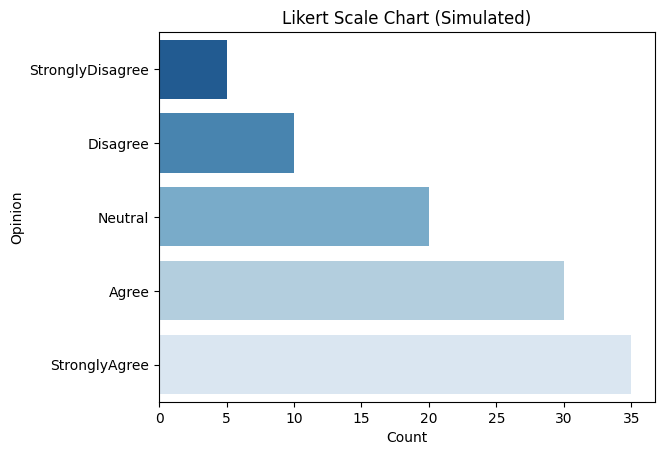

In [9]:
likert_df=pd.DataFrame({
'Opinion':['StronglyDisagree','Disagree','Neutral','Agree','StronglyAgree'], 'Count': [5, 10, 20, 30, 35]
})
sns.barplot(x='Count',y='Opinion',data=likert_df,palette='Blues_r')
plt.title("Likert Scale Chart (Simulated)")
plt.show()

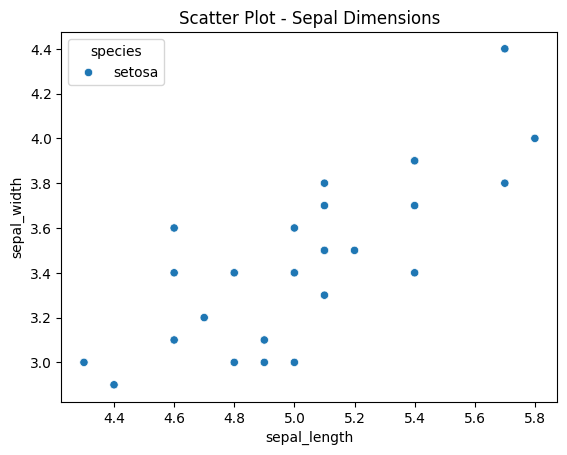

In [10]:
sns.scatterplot(data=df,x='sepal_length',y='sepal_width',hue='species',style='species')
plt.title("Scatter Plot - Sepal Dimensions")
plt.show()


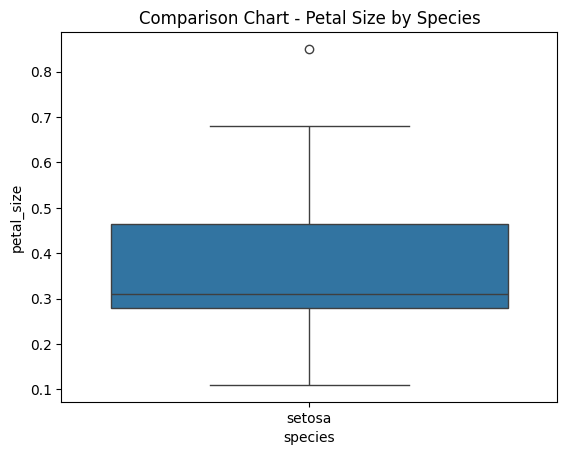

In [11]:
df['petal_size'] = df['petal_length'] * df['petal_width']
sns.boxplot(x='species', y='petal_size', data=df)
plt.title("Comparison Chart - Petal Size by Species")
plt.show()

In [13]:
df_sorted=df.sort_values('sepal_length')
diff=df_sorted['sepal_length'].diff().fillna(df_sorted['sepal_length'])
measure = ['relative'] * (len(df_sorted)-1) + ['total']
fig=go.Figure(go.Waterfall(x=df_sorted.index.astype(str),y=diff,measure=measure, base=0, name="Sepal Length Change"))
fig.update_layout(title="WaterfallChart-SepalLengthChange")
fig.show()


In [15]:
mean_values=df.groupby('species')[['sepal_length','sepal_width','petal_length', 'petal_width']].mean().reset_index()
categories=['sepal_length','sepal_width','petal_length','petal_width']
fig = go.Figure()
for i in range(len(mean_values)): fig.add_trace(go.Scatterpolar(r=mean_values.iloc[i][categories].values,theta=categories,
fill='toself', name=mean_values.iloc[i]['species'] ))
fig.update_layout(title="RadarChart-MeanMeasurementsbySpecies")
fig.show()

In [16]:
last_value=df['sepal_length'].iloc[-1]
fig=go.Figure(go.Indicator(mode="gauge+number",value=last_value,
                           title={'text': "Gauge Chart - Sepal Length"}, gauge={'axis':{'range': [0,
df['sepal_length'].max() + 1]}}	))
fig.show()


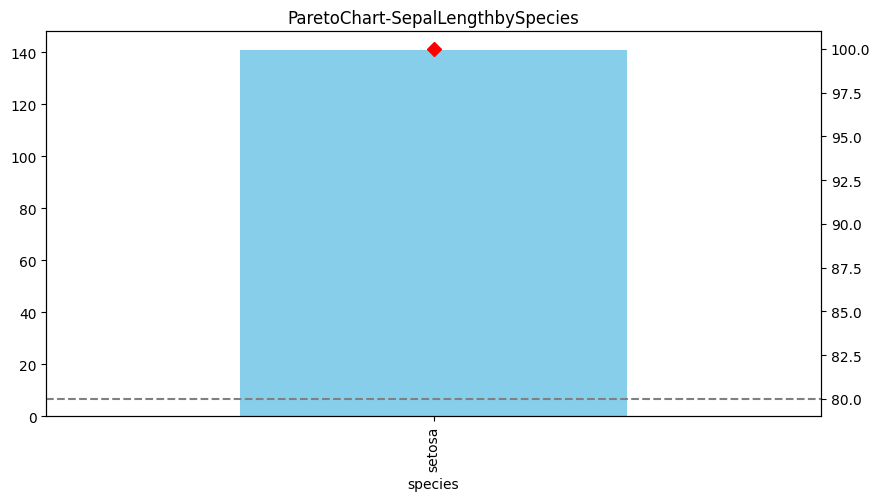

In [19]:
df_species=df.groupby('species')['sepal_length'].sum().sort_values(ascending=False)
cumperc = df_species.cumsum() / df_species.sum() * 100
fig, ax1 = plt.subplots(figsize=(10, 5))
df_species.plot(kind='bar',color="skyblue",ax=ax1)
ax2 = ax1.twinx()
ax2.plot(df_species.index,cumperc,color="red",marker="D",ms=7)
ax2.axhline(80, color='gray', linestyle='dashed')
plt.title("ParetoChart-SepalLengthbySpecies")
plt.show()

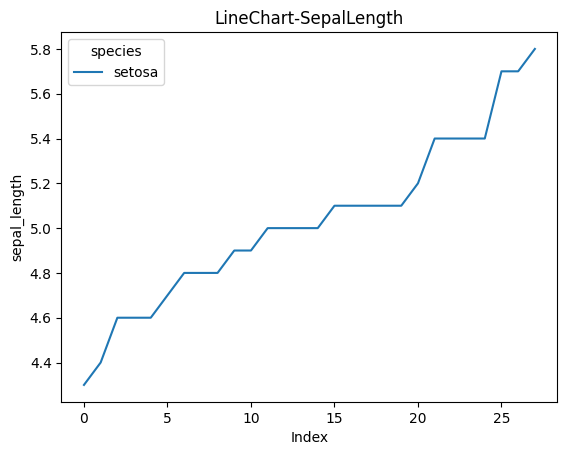

In [21]:
sns.lineplot(data=df.sort_values(by='sepal_length'),x=range(len(df)),y='sepal_length',hue='species')
plt.title("LineChart-SepalLength")
plt.xlabel("Index")
plt.show()